<a href="https://colab.research.google.com/github/qkrsj/AI-PROGRAMMING/blob/main/Week-01/03_09transfde.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0303 AI 프로그래밍


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math, os, random
import matplotlib.pyplot as plt
import numpy as np
import re
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [ ]:
# hyperparameters
EMBED_DIM = 12
NUM_HEADS = 4
FFN_DIM = 20
NUM_LAYERS = 4
SENTENCE_LENGTH = 10
BATCH_SIZE = 10
EPOCHS = 200
LEARNING_RATE = 0.001
DROPOUT = 0.1

In [ ]:
# text.txt 자리에 파일명
with open('text2.txt', 'r', encoding='utf-8') as file:
  text = file.read()

words = text.split()
word_counts = Counter(words)
stoi = {'<pad>':0, '<sos>':1, '<eos>':2, '<unk>':3}
for idx, (word, _) in enumerate(word_counts.most_common(), start=4): # sor by frequency
  stoi[word] = idx
itos = {idx: word for word, idx in stoi.items()}
vocab_size = len(stoi)
print(f"✅Vocabulary size = {vocab_size}")
print(f"✅Number of words = {len(words)}")
print(stoi)


sequences = []
targets = []
for i in range(len(words) - SENTENCE_LENGTH):
  seq = words[i:i + SENTENCE_LENGTH]
  target = words[i + 1:i + SENTENCE_LENGTH + 1]
  seq_indices = [stoi.get(w, stoi['<unk>']) for w in seq]
  target_indices = [stoi.get(w, stoi['<unk>']) for w in target]
  sequences.append(seq_indices)
  targets.append(target_indices)

X = torch.tensor(sequences)
y = torch.tensor(targets)


class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len=200):
    super().__init__()
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    return x + self.pe[:, :x.size(1), :]


✅Vocabulary size = 76
✅Number of words = 108
{'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3, '그리워': 4, '음': 5, '사랑한다는': 6, '이': 7, '밤': 8, '그날의': 9, '반딧불을': 10, '당신의': 11, '창': 12, '가까이': 13, '보낼게요': 14, '말이에요': 15, '난': 16, '파도가': 17, '머물던': 18, '모래': 19, '위에': 20, '적힌': 21, '글씨처럼': 22, '그대가': 23, '멀리': 24, '사라져': 25, '버릴': 26, '것': 27, '같아': 28, '모든': 29, '말을': 30, '다': 31, '꺼내어': 32, '줄': 33, '순': 34, '없지만': 35, '나': 36, '우리의': 37, '첫': 38, '입맞춤을': 39, '떠올려': 40, '그럼': 41, '언제든': 42, '눈을': 43, '감고': 44, '가장': 45, '먼': 46, '곳으로': 47, '가요': 48, '늘': 49, '여기': 50, '내': 51, '마음속에': 52, '어떻게': 53, '나에게': 54, '그대란': 55, '행운이': 56, '온': 57, '걸까': 58, '지금': 59, '우리': 60, '함께': 61, '있다면': 62, '아': 63, '얼마나': 64, '좋을까요': 65, '또': 66, '더': 67, '나의': 68, '일기장': 69, '안에': 70, '말': 71, '좋은': 72, '꿈': 73, '이길': 74, '바라요': 75}


In [ ]:
#신경망, CHAT GPT의 핵심부분
class TransformerDeModel(nn.Module):
  def __init__(self, vocab_size, d_model=EMBED_DIM, nhead=NUM_HEADS, num_layers=NUM_LAYERS,
                 dim_feedforward=FFN_DIM, dropout=DROPOUT):
    super().__init__()
    self.d_model = d_model
    self.embedding = nn.Embedding(vocab_size, d_model)
    self.pos_encoder = PositionalEncoding(d_model)
    decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True )
    self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
    self.fc = nn.Linear(d_model, vocab_size)
    self.dropout = nn.Dropout(dropout)
    self._init_weights()

  def _init_weights(self):
    initrange = 0.1
    self.embedding.weight.data.uniform_(-initrange, initrange)
    self.fc.bias.data.zero_()
    self.fc.weight.data.uniform_(-initrange, initrange)

  def _generate_square_subsequent_mask(self, sz):
    mask = torch.triu(torch.ones(sz, sz), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

  def forward(self, tgt, memory=None, tgt_mask=None):
    # tgt: 타겟 시퀀스 (디코더 입력) [batch_size, seq_len]
    # memory: 인코더 출력 (self-attention only이므로 None 가능)
    # tgt_mask: 타겟 마스크
    # 언어 모델링에서는 self-attention만 사용하므로 memory를 tgt와 동일하게 설정

    tgt = self.embedding(tgt) * math.sqrt(self.d_model)
    tgt = self.pos_encoder(tgt)
    tgt = self.dropout(tgt)
    if tgt_mask is None:
      tgt_mask = self._generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
    if memory is None:
      memory = tgt

    output = self.decoder(tgt, memory, tgt_mask=tgt_mask)
    output = self.fc(output)
    return output

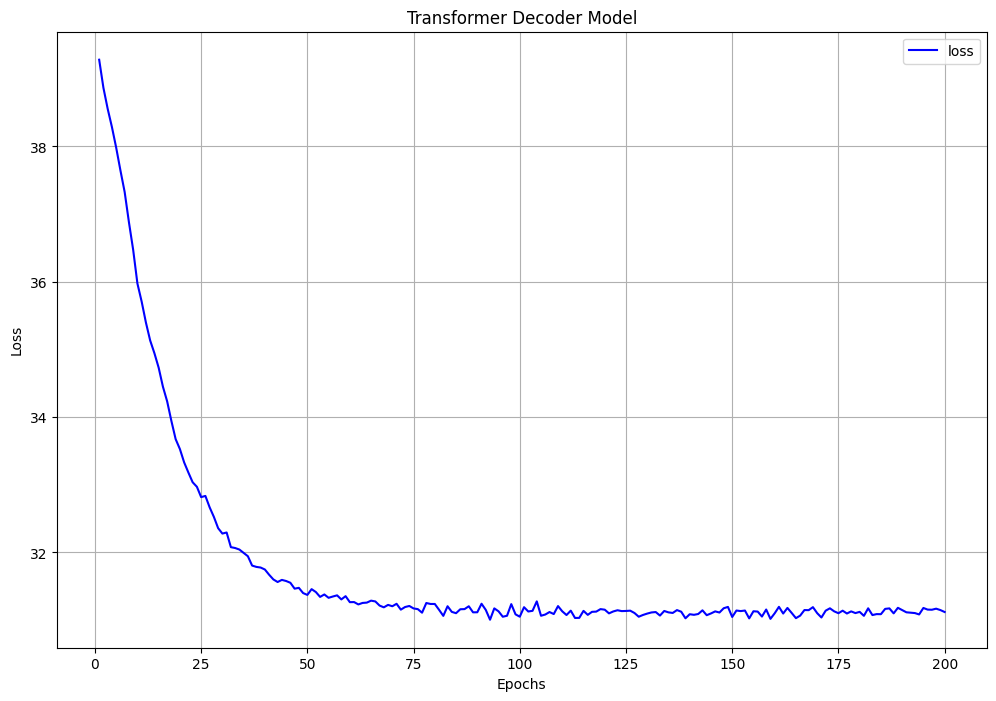

In [ ]:
#TRAINING 시키는 부분,그래프는 에러율
model = TransformerDeModel(vocab_size)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

model.train()
num_batches = len(X) // BATCH_SIZE
losses = []
for epoch in range(EPOCHS):
  sum_loss = 0
  for i in range(num_batches):
    start_idx = i * BATCH_SIZE
    end_idx = start_idx + BATCH_SIZE
    batch_X = X[start_idx:end_idx]
    batch_y = y[start_idx:end_idx]
    optimizer.zero_grad()
    output = model(batch_X)
    loss = loss_function(output.reshape(-1, vocab_size), batch_y.reshape(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
    optimizer.step()
    sum_loss += loss.item()

  losses.append(sum_loss)
  scheduler.step()


plt.figure(figsize=(12, 8))
plt.title('Transformer Decoder Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
losses_np = np.array(losses)
if len(losses_np) > 0:
    epoch_range = np.arange(1, len(losses_np) + 1)
    plt.plot(epoch_range, losses_np, color='blue', label='loss')
    plt.legend()
plt.grid(True)
plt.show()

#text.txt 그래프를 보면 EPOCHS가 대략 100부터는 쭉 비슷하기에 EPOCHS는 100정도가 효율적이다.

In [ ]:
def generate(start_text, max_length=SENTENCE_LENGTH, temperature=0.8, top_k=3):
  # max_length: 생성할 최대 단어 수
  # temperature: 생성 다양성 조절 (높을수록 다양함)
  # top_k: Top-K 샘플링 (가장 확률 높은 K개 중에서 선택)
  model.eval()
  words = start_text.lower().split()
  input_seq = [stoi.get(w, stoi['<unk>']) for w in words]

  generated = words.copy()
  with torch.no_grad():
    for _ in range(max_length - len(words)):
      x = torch.tensor([input_seq])
      output = model(x)
      last_output = output[0, -1, :]  # 마지막 출력에서 다음 단어 예측
      last_output = last_output / temperature
      if top_k > 0:
        indices_to_remove = last_output < torch.topk(last_output, top_k)[0][..., -1, None]
        last_output[indices_to_remove] = float('-inf')

      probabilities = torch.softmax(last_output, dim=0)
      next_word_idx = torch.multinomial(probabilities, 1).item()
      if next_word_idx < 4 or next_word_idx == stoi.get('<eos>', -1):
        continue

      next_word = itos[next_word_idx]
      generated.append(next_word)
      input_seq.append(next_word_idx)
      input_seq = input_seq[-20:]
  return ' '.join(generated)


while True:
  start_text = input("\n🔄 Enter starting text (or 'q' to exit): ")
  if start_text.lower() == 'q':
    break
  if not start_text.strip():
    print("❌ Empty input")
    continue

  output = generate(start_text, SENTENCE_LENGTH, 0.8, 3)
  print(f"✅ {output}")


🔄 Enter starting text (or 'q' to exit): q
